In [ ]:

#  STEP 1: Load Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils import resample


In [ ]:
#   Upload Dataset
file_path = "/content/CSHS.xlsx"
df = pd.read_excel(file_path)


In [ ]:
#  Clean column names
df.columns = df.columns.str.strip()

In [ ]:
#   Remove rows having >=4 zeros
input_cols = [
    "Course overview", "Reading file", "Abstract materiale", "Concrete material",
    "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
    "playing", "paused", "unstarted", "buffering"
]

def should_delete(row):
    zero_count = (row[input_cols] == 0).sum()
    return zero_count >= 4

df_cleaned = df[~df.apply(should_delete, axis=1)].reset_index(drop=True)


In [ ]:
#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Processing"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Processing"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input", "Understanding"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Processing'] = y_encoded["Processing"]

max_size = df_balanced['Processing'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Processing'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Processing']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.546875  0.545542  [[39, 26], [32, 31]]
XGBoost             0.515625  0.514914  [[36, 29], [33, 30]]
AdaBoost             0.53125  0.522844  [[43, 22], [38, 25]]
Bagging             0.476562  0.471946  [[37, 28], [39, 24]]
ExtraTrees            0.5625    0.5625  [[36, 29], [27, 36]]
LogisticRegression  0.460938  0.459782  [[33, 32], [37, 26]]
NaiveBayes          0.515625  0.471273  [[52, 13], [49, 14]]
SVM                 0.523438  0.502889  [[47, 18], [43, 20]]
KNN                 0.664062  0.663343  [[46, 19], [24, 39]]
DecisionTree             0.5  0.499756  [[31, 34], [30, 33]]


In [ ]:
#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Perception"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Perception"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input", "Understanding"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Perception'] = y_encoded["Perception"]

max_size = df_balanced['Perception'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Perception'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Perception']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.970874  0.970896   [[96, 1], [5, 104]]
XGBoost             0.883495  0.883055   [[95, 2], [22, 87]]
AdaBoost            0.601942  0.602242  [[58, 39], [43, 66]]
Bagging             0.917476  0.917388   [[96, 1], [16, 93]]
ExtraTrees          0.990291  0.990291   [[96, 1], [1, 108]]
LogisticRegression  0.524272  0.524631  [[52, 45], [53, 56]]
NaiveBayes          0.587379  0.534415  [[23, 74], [11, 98]]
SVM                 0.703883   0.70042  [[81, 16], [45, 64]]
KNN                 0.791262  0.787252   [[93, 4], [39, 70]]
DecisionTree        0.907767  0.907478   [[97, 0], [19, 90]]


In [ ]:

#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Input"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Input"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input", "Understanding"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Input'] = y_encoded["Input"]

max_size = df_balanced['Input'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Input'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Input']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.951613   0.95162    [[89, 7], [2, 88]]
XGBoost             0.795699  0.795604  [[73, 23], [15, 75]]
AdaBoost            0.548387  0.543727  [[62, 34], [50, 40]]
Bagging             0.897849   0.89745   [[79, 17], [2, 88]]
ExtraTrees          0.973118  0.973122    [[93, 3], [2, 88]]
LogisticRegression   0.55914   0.55914  [[55, 41], [41, 49]]
NaiveBayes          0.505376  0.445178  [[79, 17], [75, 15]]
SVM                 0.639785  0.637186  [[69, 27], [40, 50]]
KNN                  0.61828  0.611943  [[47, 49], [22, 68]]
DecisionTree        0.860215  0.858453   [[71, 25], [1, 89]]


In [ ]:

#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Understanding"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Understanding"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input", "Understanding"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Understanding'] = y_encoded["Understanding"]

max_size = df_balanced['Understanding'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Understanding'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Understanding']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.760736  0.758093  [[75, 14], [25, 49]]
XGBoost             0.674847  0.674178  [[64, 25], [28, 46]]
AdaBoost            0.595092  0.592741  [[45, 44], [22, 52]]
Bagging             0.754601  0.746674   [[80, 9], [31, 43]]
ExtraTrees          0.815951  0.816257  [[72, 17], [13, 61]]
LogisticRegression  0.509202  0.507353  [[39, 50], [30, 44]]
NaiveBayes          0.447853  0.413528  [[20, 69], [21, 53]]
SVM                 0.570552  0.549253  [[32, 57], [13, 61]]
KNN                 0.680982  0.679443  [[66, 23], [29, 45]]
DecisionTree        0.779141  0.774863  [[79, 10], [26, 48]]


In [ ]:
#   Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Processing"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Processing"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Processing"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Processing"]].head(20))


           id Predicted Processing
610  0108E196                  REF
611  0124Y179                  REF
612  2120Y890                  REF
613  0137Q847                  ACT
614  0133E024                  ACT
615  2130U049                  ACT
616  2130W464                  REF
617  2130V610                  REF
618  2130U811                  ACT
619  0145E424                  ACT
620  0146T511                  ACT
621  0145Z518                  ACT
622  0144W650                  ACT
623  0103C618                  REF
624  0119I973                  ACT
625  0146H849                  REF
626  0147Z304                  REF
627  0147H705                  ACT
628  0147F999                  ACT
629  R.SaCidi                  REF


In [ ]:
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsProcessing.csv", index=False)
print("Saved as CSV.")


Saved as CSV.


In [ ]:
#  Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Perception"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Perception"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Perception"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Perception"]].head(20))
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsPerception.csv", index=False)
print("Saved as CSV.")



           id Predicted Perception
610  0108E196                  SEN
611  0124Y179                  SEN
612  2120Y890                  SEN
613  0137Q847                  SEN
614  0133E024                  SEN
615  2130U049                  SEN
616  2130W464                  SEN
617  2130V610                  SEN
618  2130U811                  SEN
619  0145E424                  SEN
620  0146T511                  SEN
621  0145Z518                  SEN
622  0144W650                  SEN
623  0103C618                  SEN
624  0119I973                  SEN
625  0146H849                  SEN
626  0147Z304                  SEN
627  0147H705                  SEN
628  0147F999                  SEN
629  R.SaCidi                  SEN
Saved as CSV.


In [ ]:
#   Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Input"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Input"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Input"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Input"]].head(20))
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsInput.csv", index=False)
print("Saved as CSV.")


           id Predicted Input
610  0108E196             VIS
611  0124Y179             VIS
612  2120Y890             VIS
613  0137Q847             VIS
614  0133E024             VIS
615  2130U049             VIS
616  2130W464             VIS
617  2130V610             VIS
618  2130U811             VIS
619  0145E424             VIS
620  0146T511             VIS
621  0145Z518             VIS
622  0144W650             VIS
623  0103C618             VIS
624  0119I973             VIS
625  0146H849             VIS
626  0147Z304             VIS
627  0147H705             VIS
628  0147F999             VIS
629  R.SaCidi             VIS
Saved as CSV.


In [ ]:
#  Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

# Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Understanding"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

# Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Understanding"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Understanding"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Understanding"]].head(20))
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsUnderstanding.csv", index=False)
print("Saved as CSV.")

           id Predicted Understanding
610  0108E196                     SEQ
611  0124Y179                     SEQ
612  2120Y890                     GLO
613  0137Q847                     SEQ
614  0133E024                     SEQ
615  2130U049                     SEQ
616  2130W464                     GLO
617  2130V610                     GLO
618  2130U811                     SEQ
619  0145E424                     SEQ
620  0146T511                     SEQ
621  0145Z518                     SEQ
622  0144W650                     SEQ
623  0103C618                     SEQ
624  0119I973                     SEQ
625  0146H849                     GLO
626  0147Z304                     SEQ
627  0147H705                     SEQ
628  0147F999                     SEQ
629  R.SaCidi                     SEQ
Saved as CSV.


In [ ]:
# INSTALL LIBRARY (uncomment if needed)
# !pip install imbalanced-learn

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

# DEFINE FILES AND TARGET COLUMN NAMES
files_targets = {
    "Unlabelled_with_Predicted_LabelsProcessing.csv": "Predicted Processing",
    "Unlabelled_with_Predicted_LabelsPerception.csv": "Predicted Perception",
    "Unlabelled_with_Predicted_LabelsInput.csv": "Predicted Input",
    "Unlabelled_with_Predicted_LabelsUnderstanding.csv": "Predicted Understanding"
}

# INPUT COLUMNS
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# TO STORE ALL RESULTS
final_results = {}

# LOOP THROUGH EACH FILE AND TRAIN MODELS
for file, target_column in files_targets.items():
    print("\n=============================")
    print(" FILE:", file, "| TARGET:", target_column)
    print("=============================")

    # Load data
    df = pd.read_csv("/content/" + file)

    # Prepare input and target
    X = df[input_cols]
    y = df[target_column]

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Scale inputs
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Check smallest class count
    class_counts = Counter(y_encoded)
    min_class_samples = min(class_counts.values())

    # Apply SMOTE if enough samples
    if min_class_samples > 5:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)
        print("SMOTE Applied → Class Distribution:", np.bincount(y_balanced))
    else:
        X_balanced, y_balanced = X_scaled, y_encoded
        print("⚠️ SMOTE Skipped → Not enough samples in smallest class:", min_class_samples)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

    # Define Models
    models = {
        "RandomForest": RandomForestClassifier(),
        "XGBoost": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Bagging": BaggingClassifier(),
        "ExtraTrees": ExtraTreesClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "NaiveBayes": GaussianNB(),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier()
    }

    results = {}

    # Train and evaluate models
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Confusion Matrix": cm
        }

    # Save results
    results_df = pd.DataFrame(results).T
    final_results[target_column] = results_df

# FINAL RESULTS PRINTING
for target, result_df in final_results.items():
    print("\n===============================")
    print("📌 FINAL RESULT →", target.upper())
    print("===============================")
    print(result_df)



 FILE: Unlabelled_with_Predicted_LabelsProcessing.csv | TARGET: Predicted Processing
SMOTE Applied → Class Distribution: [391 391]

 FILE: Unlabelled_with_Predicted_LabelsPerception.csv | TARGET: Predicted Perception
SMOTE Applied → Class Distribution: [746 746]

 FILE: Unlabelled_with_Predicted_LabelsInput.csv | TARGET: Predicted Input
⚠️ SMOTE Skipped → Not enough samples in smallest class: 3

 FILE: Unlabelled_with_Predicted_LabelsUnderstanding.csv | TARGET: Predicted Understanding
SMOTE Applied → Class Distribution: [677 677]

📌 FINAL RESULT → PREDICTED PROCESSING
                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.802548  0.802403  [[66, 14], [17, 60]]
XGBoost             0.802548  0.802227  [[67, 13], [18, 59]]
AdaBoost            0.707006  0.706362  [[60, 20], [26, 51]]
Bagging             0.783439  0.782663  [[67, 13], [21, 56]]
ExtraTrees           0.77707  0.777088  [[62, 18], [17, 60]]
LogisticRegression  0.726115  0.726115  [[57, 23], [20, 57


 FILE: Unlabelled_with_Predicted_LabelsProcessing.csv | TARGET: Predicted Processing
✅ SMOTE Applied → Class Distribution: [391 391]

📌 Model: RandomForest
Accuracy: 0.8152866242038217
Precision: 0.8156132880635989
Recall: 0.8152866242038217
Specificity: 0.8375
F1 Score: 0.8151515394614363
Cohen Kappa: 0.6301681423117538
Log Loss: 0.4172960940367084
Train Time (s): 0.19225263595581055
Test Time (s): 0.007781028747558594
Confusion Matrix:
 [[67 13]
 [16 61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82        80
           1       0.82      0.79      0.81        77

    accuracy                           0.82       157
   macro avg       0.82      0.81      0.82       157
weighted avg       0.82      0.82      0.82       157



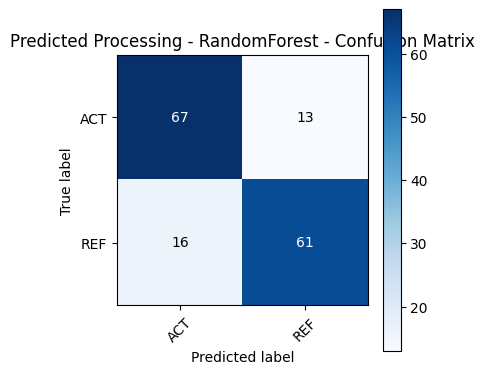

AUC Score: 0.8921266233766234


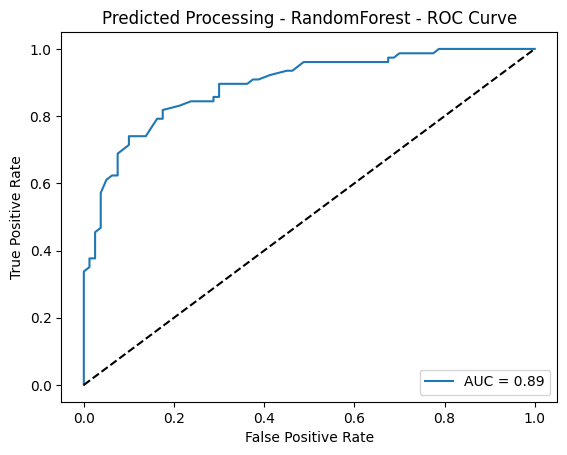


📌 Model: XGBoost
Accuracy: 0.802547770700637
Precision: 0.8035416926855667
Recall: 0.802547770700637
Specificity: 0.8375
F1 Score: 0.8022265142771278
Cohen Kappa: 0.6044697277529459
Log Loss: 0.49896973809504214
Train Time (s): 0.2189006805419922
Test Time (s): 0.0009624958038330078
Confusion Matrix:
 [[67 13]
 [18 59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81        80
           1       0.82      0.77      0.79        77

    accuracy                           0.80       157
   macro avg       0.80      0.80      0.80       157
weighted avg       0.80      0.80      0.80       157



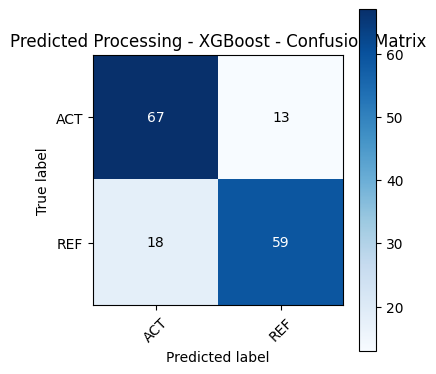

AUC Score: 0.8425324675324676


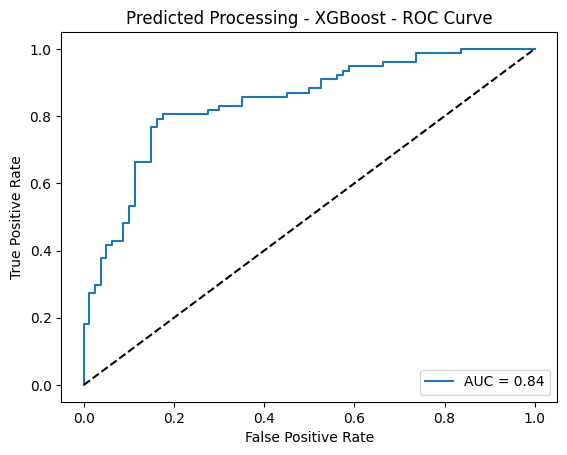


📌 Model: AdaBoost
Accuracy: 0.7070063694267515
Precision: 0.7077949849891827
Recall: 0.7070063694267515
Specificity: 0.75
F1 Score: 0.7063623749603336
Cohen Kappa: 0.4129409852056577
Log Loss: 0.6047594474885581
Train Time (s): 0.16062450408935547
Test Time (s): 0.014181137084960938
Confusion Matrix:
 [[60 20]
 [26 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.75      0.72        80
           1       0.72      0.66      0.69        77

    accuracy                           0.71       157
   macro avg       0.71      0.71      0.71       157
weighted avg       0.71      0.71      0.71       157



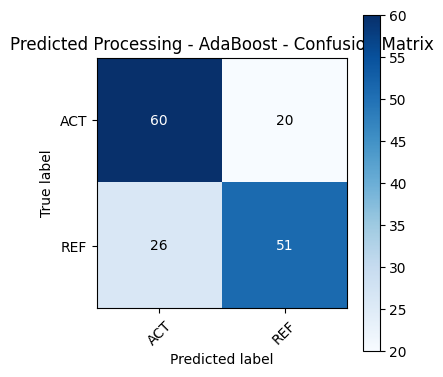

AUC Score: 0.8060064935064934


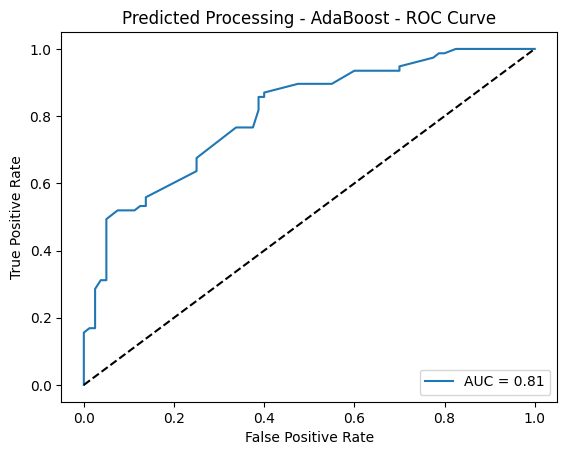


📌 Model: Bagging
Accuracy: 0.7515923566878981
Precision: 0.7521414095458682
Recall: 0.7515923566878981
Specificity: 0.7375
F1 Score: 0.7515923566878981
Cohen Kappa: 0.5033660475302133
Log Loss: 0.6555913339531556
Train Time (s): 0.06006169319152832
Test Time (s): 0.002958059310913086
Confusion Matrix:
 [[59 21]
 [18 59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.74      0.75        80
           1       0.74      0.77      0.75        77

    accuracy                           0.75       157
   macro avg       0.75      0.75      0.75       157
weighted avg       0.75      0.75      0.75       157



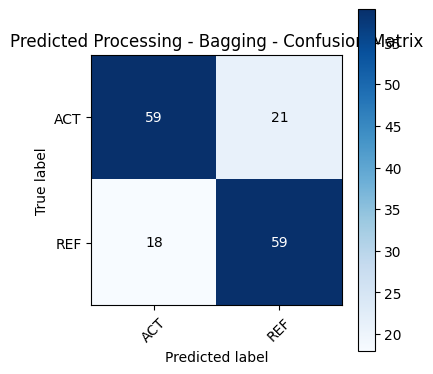

AUC Score: 0.86737012987013


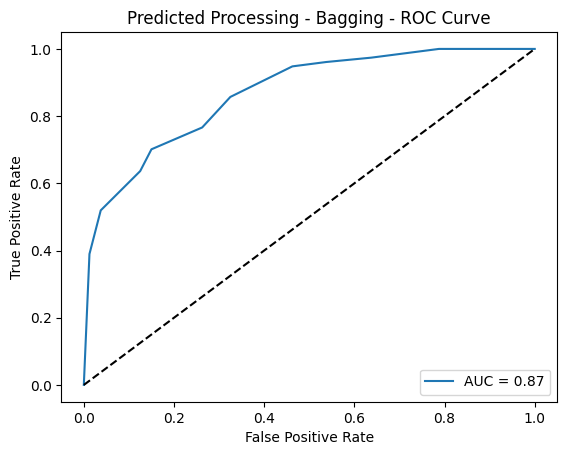


📌 Model: ExtraTrees
Accuracy: 0.7770700636942676
Precision: 0.7773127282758163
Recall: 0.7770700636942676
Specificity: 0.8
F1 Score: 0.776907030384492
Cohen Kappa: 0.5536512062383234
Log Loss: 0.4397519137732918
Train Time (s): 0.2431774139404297
Test Time (s): 0.01547384262084961
Confusion Matrix:
 [[64 16]
 [19 58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79        80
           1       0.78      0.75      0.77        77

    accuracy                           0.78       157
   macro avg       0.78      0.78      0.78       157
weighted avg       0.78      0.78      0.78       157



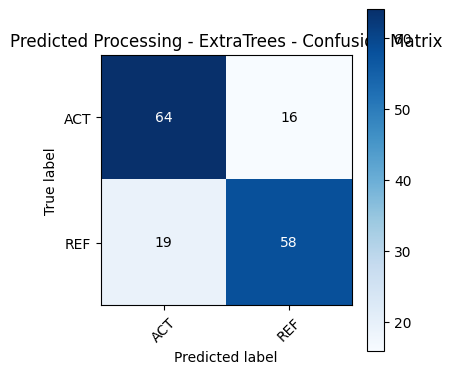

AUC Score: 0.8814935064935064


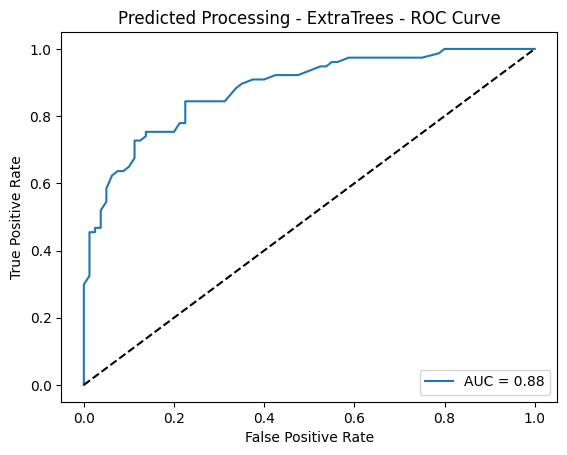


📌 Model: LogisticRegression
Accuracy: 0.7261146496815286
Precision: 0.7266450905782116
Recall: 0.7261146496815286
Specificity: 0.7125
F1 Score: 0.7261146496815286
Cohen Kappa: 0.45242923189228645
Log Loss: 0.5713653631665594
Train Time (s): 0.008002758026123047
Test Time (s): 0.0004570484161376953
Confusion Matrix:
 [[57 23]
 [20 57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.73        80
           1       0.71      0.74      0.73        77

    accuracy                           0.73       157
   macro avg       0.73      0.73      0.73       157
weighted avg       0.73      0.73      0.73       157



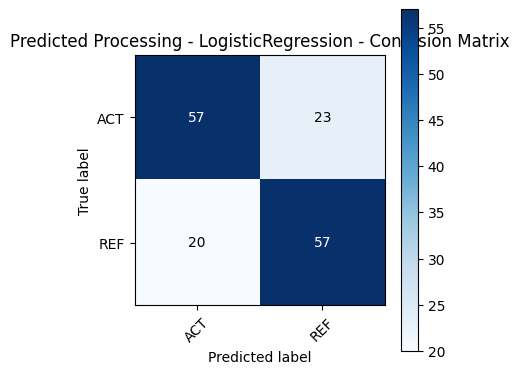

AUC Score: 0.7896103896103894


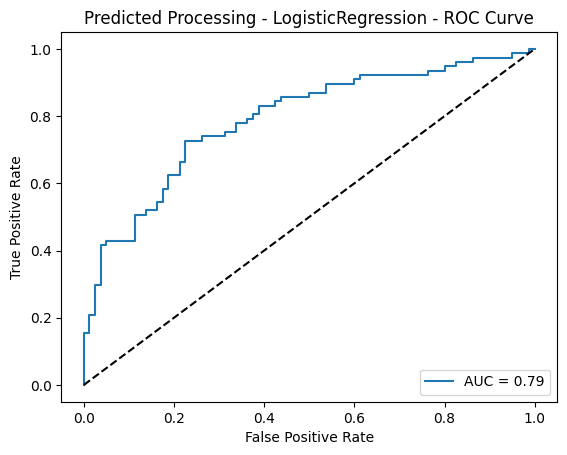


📌 Model: NaiveBayes
Accuracy: 0.6751592356687898
Precision: 0.7160528016246654
Recall: 0.6751592356687898
Specificity: 0.9
F1 Score: 0.6565409113179814
Cohen Kappa: 0.344494474007368
Log Loss: 2.301179827308703
Train Time (s): 0.0016438961029052734
Test Time (s): 0.00041103363037109375
Confusion Matrix:
 [[72  8]
 [43 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.90      0.74        80
           1       0.81      0.44      0.57        77

    accuracy                           0.68       157
   macro avg       0.72      0.67      0.65       157
weighted avg       0.72      0.68      0.66       157



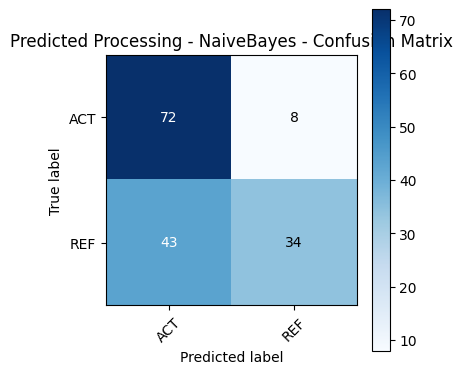

AUC Score: 0.7448051948051947


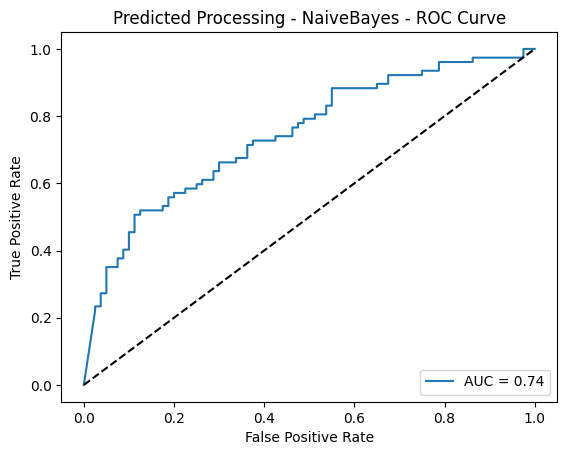


📌 Model: SVM
Accuracy: 0.6942675159235668
Precision: 0.7062912057213098
Recall: 0.6942675159235668
Specificity: 0.825
F1 Score: 0.6884367969071838
Cohen Kappa: 0.3853181076672104
Log Loss: 0.5419929697979925
Train Time (s): 0.06614232063293457
Test Time (s): 0.0033369064331054688
Confusion Matrix:
 [[66 14]
 [34 43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.82      0.73        80
           1       0.75      0.56      0.64        77

    accuracy                           0.69       157
   macro avg       0.71      0.69      0.69       157
weighted avg       0.71      0.69      0.69       157



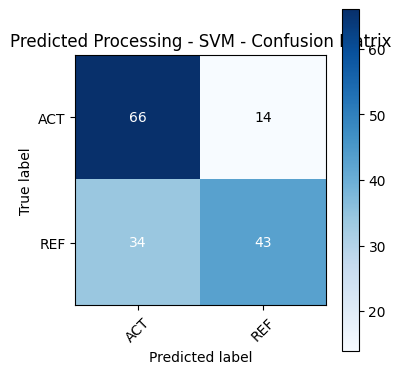

AUC Score: 0.7899350649350649


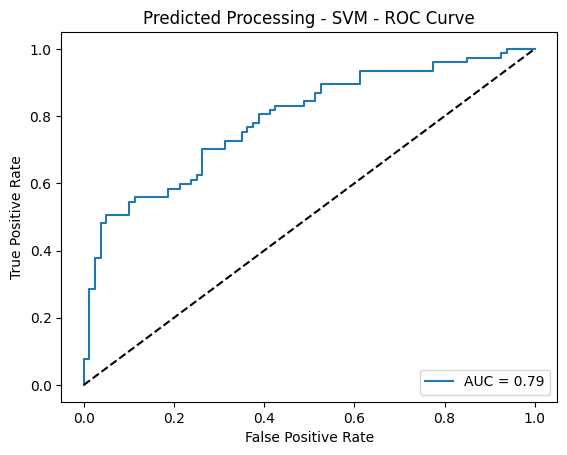


📌 Model: KNN
Accuracy: 0.7261146496815286
Precision: 0.7262453152254396
Recall: 0.7261146496815286
Specificity: 0.75
F1 Score: 0.7259143516152331
Cohen Kappa: 0.4516286248070831
Log Loss: 1.5990941182069585
Train Time (s): 0.0017139911651611328
Test Time (s): 0.014870166778564453
Confusion Matrix:
 [[60 20]
 [23 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.74        80
           1       0.73      0.70      0.72        77

    accuracy                           0.73       157
   macro avg       0.73      0.73      0.73       157
weighted avg       0.73      0.73      0.73       157



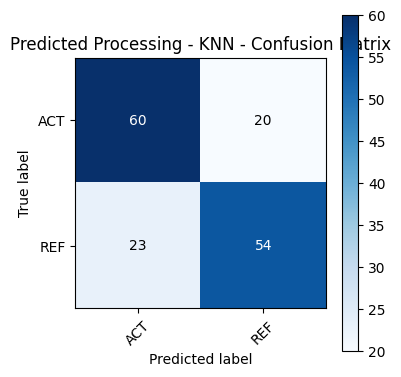

AUC Score: 0.7877435064935063


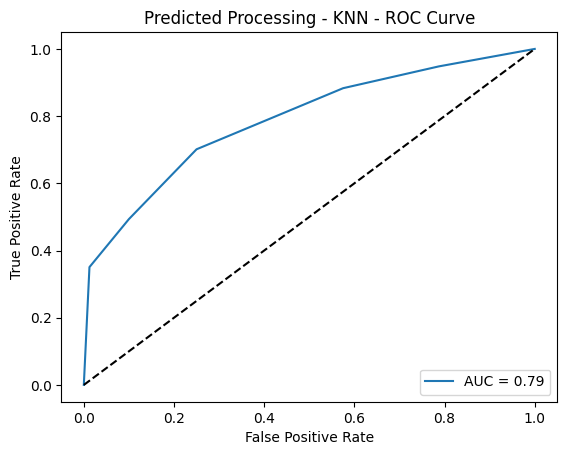


📌 Model: DecisionTree
Accuracy: 0.7388535031847133
Precision: 0.7443229022431459
Recall: 0.7388535031847133
Specificity: 0.675
F1 Score: 0.7379187506234058
Cohen Kappa: 0.4789120051809277
Log Loss: 9.412673814992377
Train Time (s): 0.006989955902099609
Test Time (s): 0.001249551773071289
Confusion Matrix:
 [[54 26]
 [15 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.68      0.72        80
           1       0.70      0.81      0.75        77

    accuracy                           0.74       157
   macro avg       0.74      0.74      0.74       157
weighted avg       0.74      0.74      0.74       157



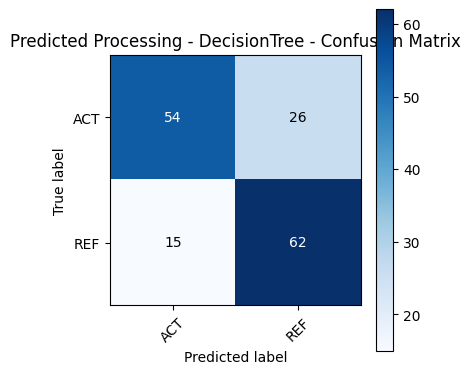

AUC Score: 0.7400974025974026


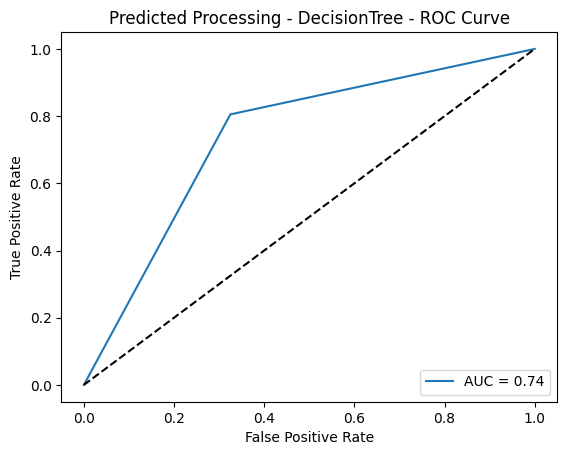


 FILE: Unlabelled_with_Predicted_LabelsPerception.csv | TARGET: Predicted Perception
✅ SMOTE Applied → Class Distribution: [746 746]

📌 Model: RandomForest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.0029616981644312542
Train Time (s): 0.20065546035766602
Test Time (s): 0.006680011749267578
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



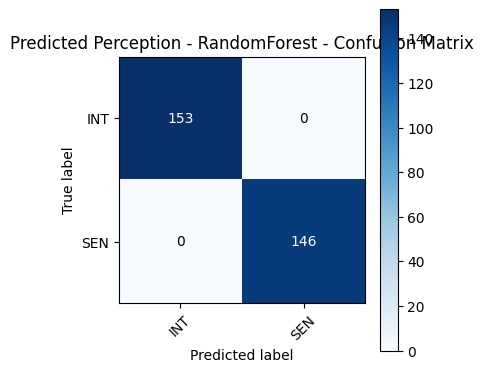

AUC Score: 1.0


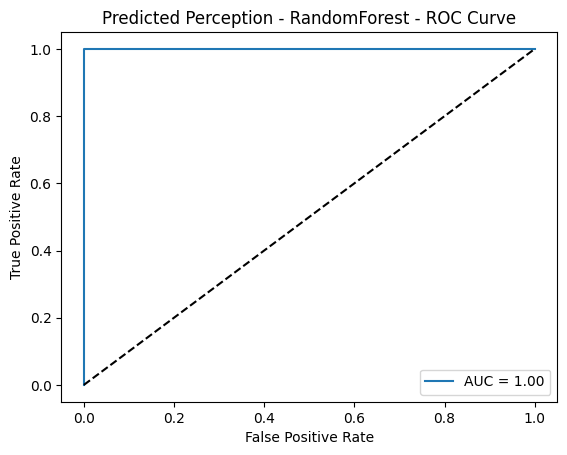


📌 Model: XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 2.1904761037724592e-05
Train Time (s): 0.21450328826904297
Test Time (s): 0.0006239414215087891
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



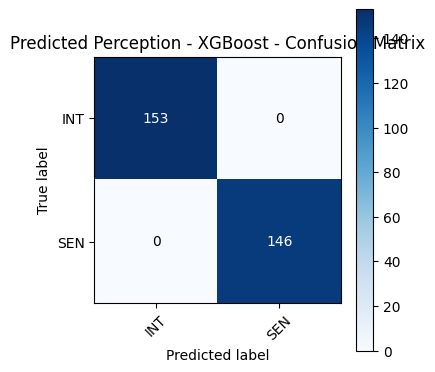

AUC Score: 1.0


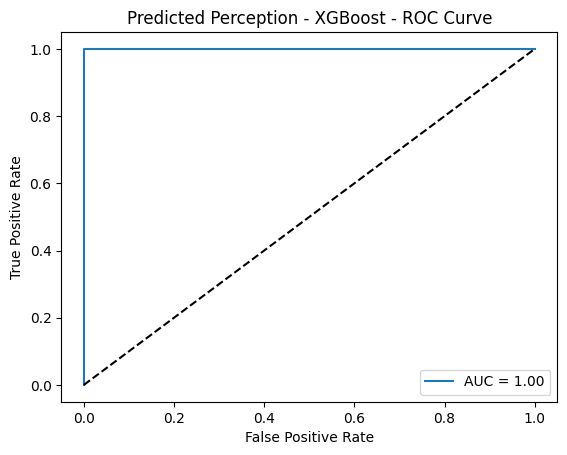


📌 Model: AdaBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.12692801104297238
Train Time (s): 0.00581669807434082
Test Time (s): 0.0005702972412109375
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



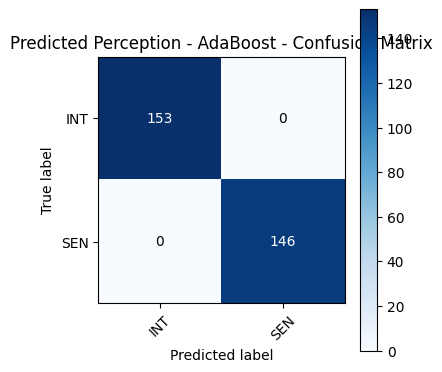

AUC Score: 1.0


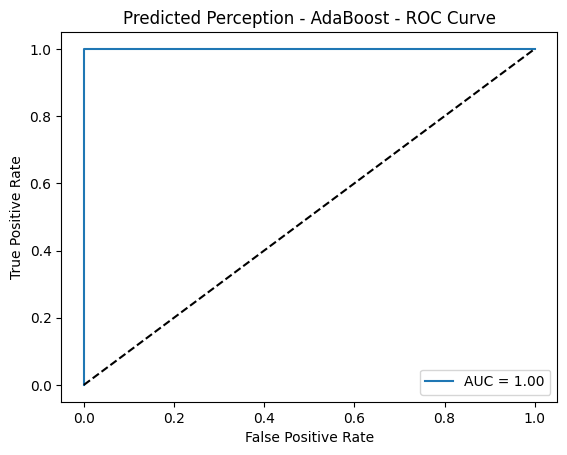


📌 Model: Bagging
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 2.2204460492503136e-16
Train Time (s): 0.040840864181518555
Test Time (s): 0.003579854965209961
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



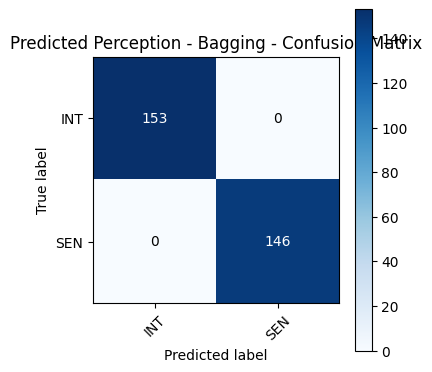

AUC Score: 1.0


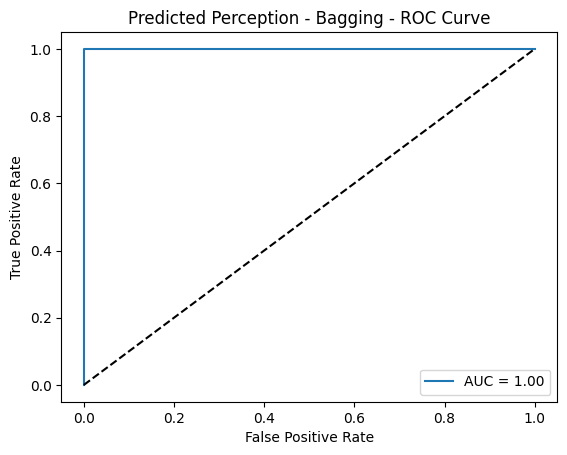


📌 Model: ExtraTrees
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.010037388612065413
Train Time (s): 0.11908960342407227
Test Time (s): 0.007382392883300781
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



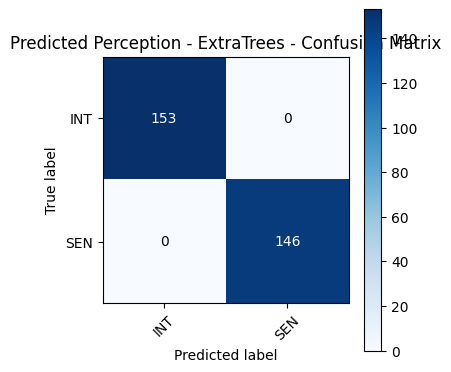

AUC Score: 1.0


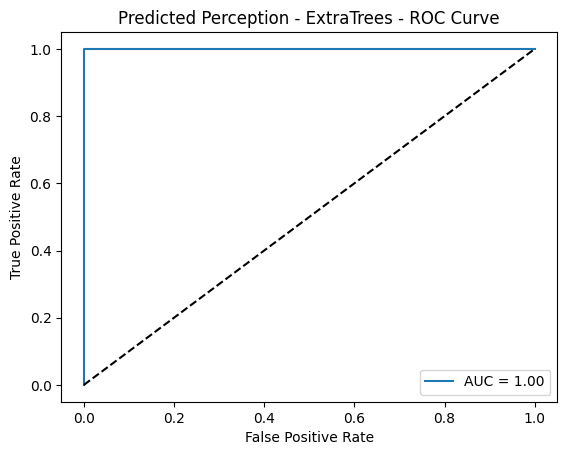


📌 Model: LogisticRegression
Accuracy: 0.9866220735785953
Precision: 0.9869629124683125
Recall: 0.9866220735785953
Specificity: 1.0
F1 Score: 0.9866154805144989
Cohen Kappa: 0.9732126858985845
Log Loss: 0.0626997158889515
Train Time (s): 0.030312299728393555
Test Time (s): 0.0004329681396484375
Confusion Matrix:
 [[153   0]
 [  4 142]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       153
           1       1.00      0.97      0.99       146

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



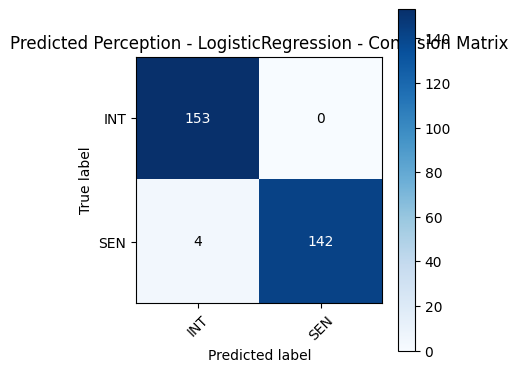

AUC Score: 0.9994180320530038


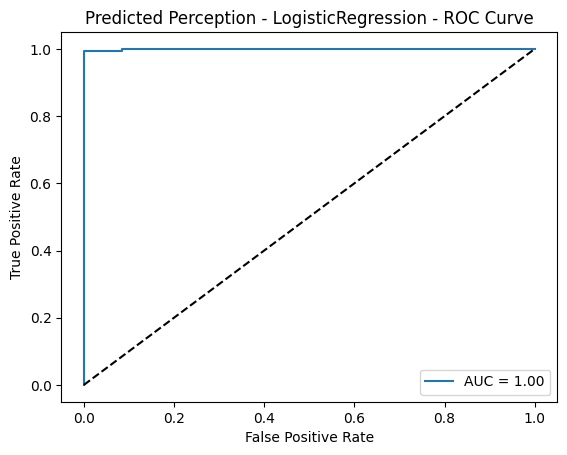


📌 Model: NaiveBayes
Accuracy: 0.9933110367892977
Precision: 0.9933973459920163
Recall: 0.9933110367892977
Specificity: 1.0
F1 Score: 0.9933096888119376
Cohen Kappa: 0.9866105413998477
Log Loss: 0.13243107077087019
Train Time (s): 0.002142667770385742
Test Time (s): 0.0004942417144775391
Confusion Matrix:
 [[153   0]
 [  2 144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       153
           1       1.00      0.99      0.99       146

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



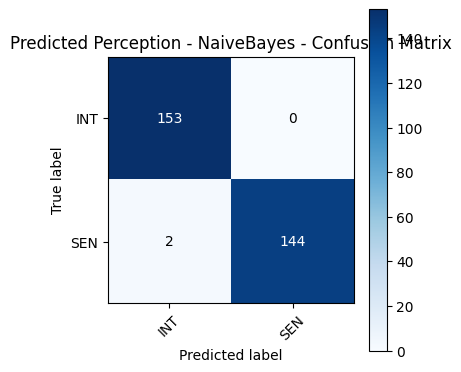

AUC Score: 0.9974482943862477


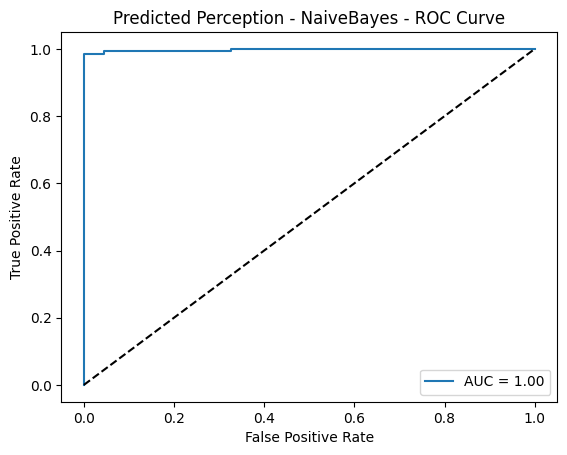


📌 Model: SVM
Accuracy: 0.9899665551839465
Precision: 0.9901595060457935
Recall: 0.9899665551839465
Specificity: 1.0
F1 Score: 0.9899631845235454
Cohen Kappa: 0.9799126637554585
Log Loss: 0.01718428862354219
Train Time (s): 0.06936287879943848
Test Time (s): 0.0023641586303710938
Confusion Matrix:
 [[153   0]
 [  3 143]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       153
           1       1.00      0.98      0.99       146

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



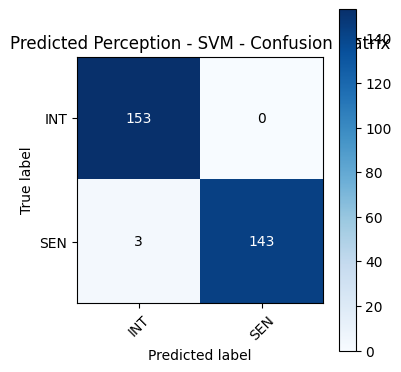

AUC Score: 1.0


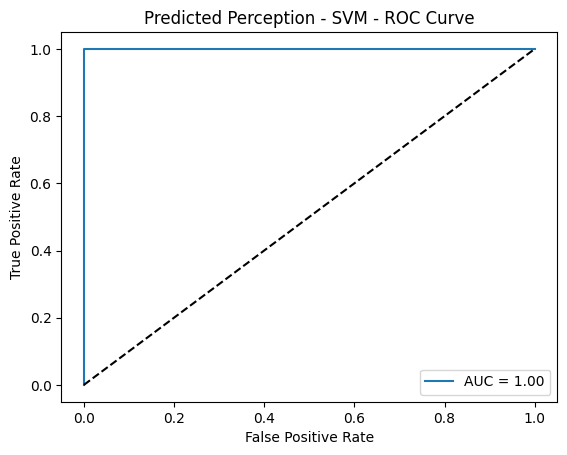


📌 Model: KNN
Accuracy: 0.979933110367893
Precision: 0.9806903514860855
Recall: 0.979933110367893
Specificity: 1.0
F1 Score: 0.9799155693804522
Cohen Kappa: 0.959806425594838
Log Loss: 0.3794193411431522
Train Time (s): 0.0027551651000976562
Test Time (s): 0.023079872131347656
Confusion Matrix:
 [[153   0]
 [  6 140]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       153
           1       1.00      0.96      0.98       146

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



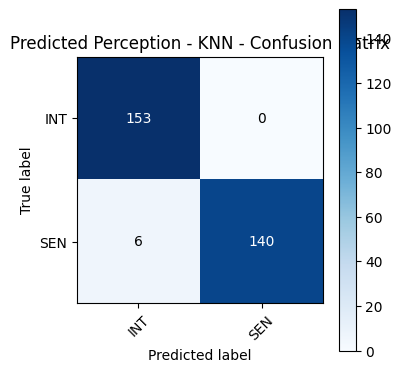

AUC Score: 0.9897260273972603


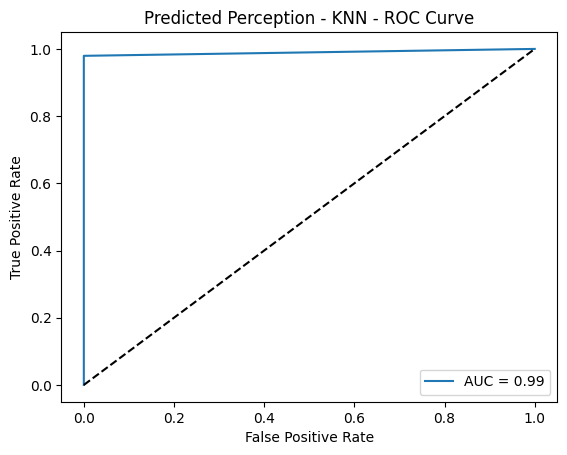


📌 Model: DecisionTree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 2.2204460492503136e-16
Train Time (s): 0.0030634403228759766
Test Time (s): 0.0003540515899658203
Confusion Matrix:
 [[153   0]
 [  0 146]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       146

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



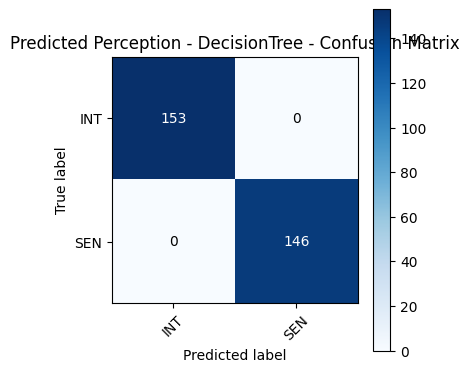

AUC Score: 1.0


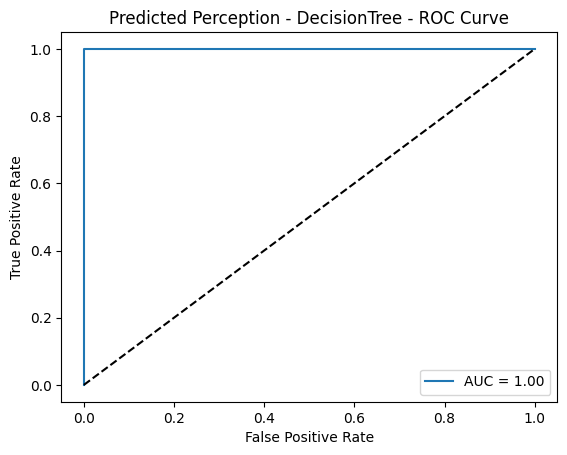


 FILE: Unlabelled_with_Predicted_LabelsInput.csv | TARGET: Predicted Input
⚠️ SMOTE Skipped → Not enough samples in smallest class: 3

📌 Model: RandomForest
Accuracy: 0.9933774834437086
Precision: 0.9867988246129555
Recall: 0.9933774834437086
Specificity: 1.0
F1 Score: 0.9900772260236298
Cohen Kappa: 0.0
Log Loss: 0.2442190371902325
Train Time (s): 0.1685771942138672
Test Time (s): 0.006053924560546875
Confusion Matrix:
 [[150   0]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


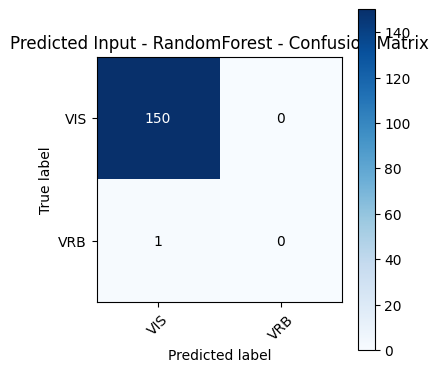

AUC Score: 0.47


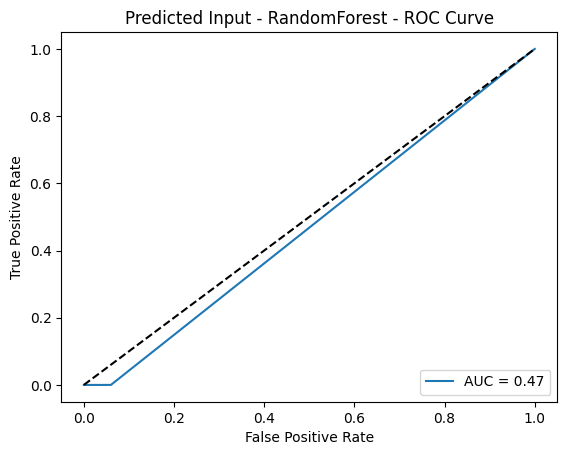


📌 Model: XGBoost
Accuracy: 0.9801324503311258
Precision: 0.9867105204675765
Recall: 0.9801324503311258
Specificity: 0.9866666666666667
F1 Score: 0.9834104852820661
Cohen Kappa: -0.008908685968819663
Log Loss: 0.4722446772286978
Train Time (s): 0.14981579780578613
Test Time (s): 0.0006422996520996094
Confusion Matrix:
 [[148   2]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.00      0.00      0.00         1

    accuracy                           0.98       151
   macro avg       0.50      0.49      0.49       151
weighted avg       0.99      0.98      0.98       151



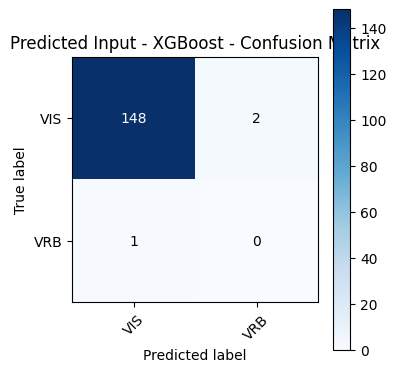

AUC Score: 0.49333333333333335


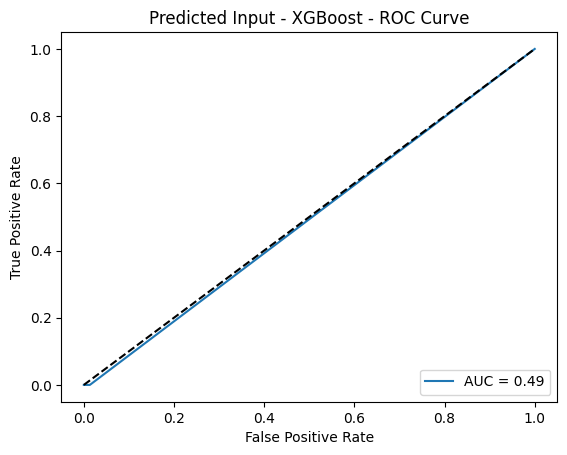


📌 Model: AdaBoost
Accuracy: 0.9867549668874173
Precision: 0.9867549668874173
Recall: 0.9867549668874173
Specificity: 0.9933333333333333
F1 Score: 0.9867549668874173
Cohen Kappa: -0.006666666666666599
Log Loss: 0.2872231272156848
Train Time (s): 0.11945748329162598
Test Time (s): 0.007997512817382812
Confusion Matrix:
 [[149   1]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



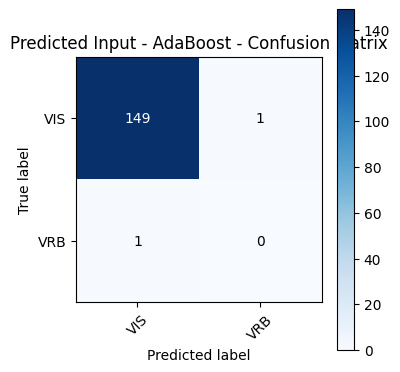

AUC Score: 0.6066666666666667


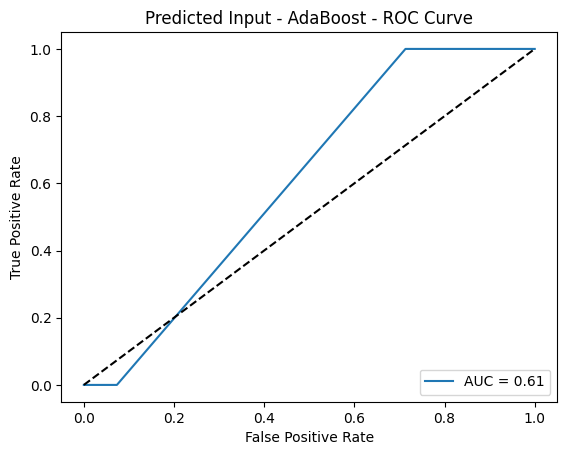


📌 Model: Bagging
Accuracy: 0.9867549668874173
Precision: 0.9867549668874173
Recall: 0.9867549668874173
Specificity: 0.9933333333333333
F1 Score: 0.9867549668874173
Cohen Kappa: -0.006666666666666599
Log Loss: 0.25075372405872143
Train Time (s): 0.03138327598571777
Test Time (s): 0.0019941329956054688
Confusion Matrix:
 [[149   1]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



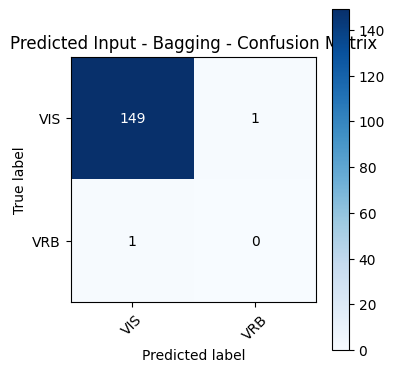

AUC Score: 0.49


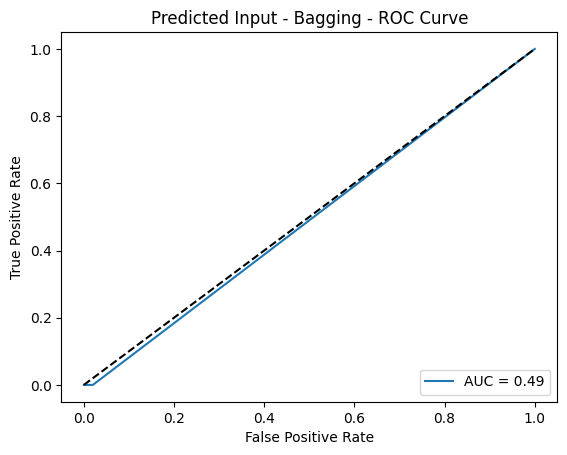


📌 Model: ExtraTrees
Accuracy: 0.9933774834437086
Precision: 0.9867988246129555
Recall: 0.9933774834437086
Specificity: 1.0
F1 Score: 0.9900772260236298
Cohen Kappa: 0.0
Log Loss: 0.24445726477842353
Train Time (s): 0.10336422920227051
Test Time (s): 0.0060634613037109375
Confusion Matrix:
 [[150   0]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


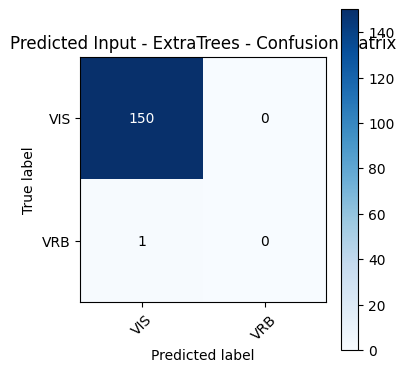

AUC Score: 0.45


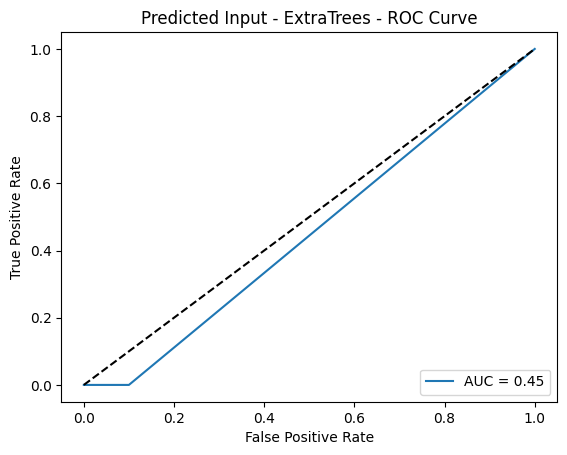


📌 Model: LogisticRegression
Accuracy: 0.9933774834437086
Precision: 0.9867988246129555
Recall: 0.9933774834437086
Specificity: 1.0
F1 Score: 0.9900772260236298
Cohen Kappa: 0.0
Log Loss: 0.08077778584355644
Train Time (s): 0.005837202072143555
Test Time (s): 0.00038504600524902344
Confusion Matrix:
 [[150   0]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


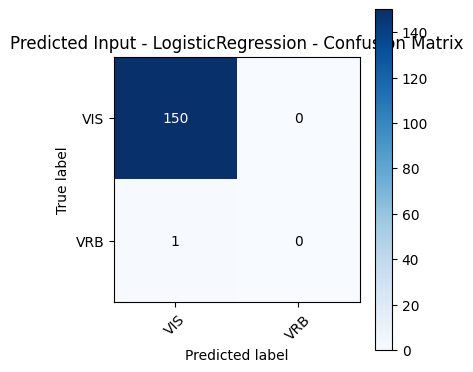

AUC Score: 0.11333333333333329


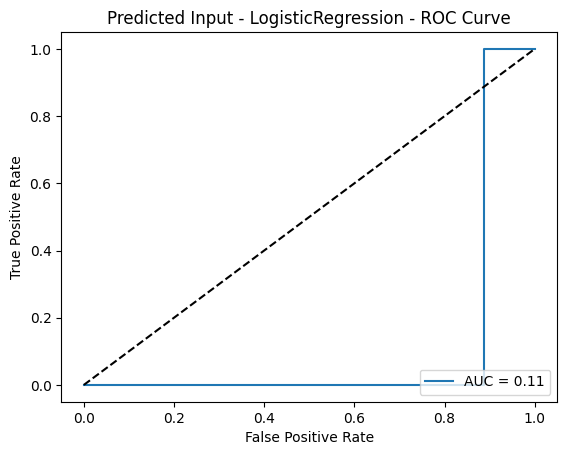


📌 Model: NaiveBayes
Accuracy: 0.9668874172185431
Precision: 0.9866198134883093
Recall: 0.9668874172185431
Specificity: 0.9733333333333334
F1 Score: 0.976653956786407
Cohen Kappa: -0.010709504685408433
Log Loss: 0.6981520515888484
Train Time (s): 0.0018072128295898438
Test Time (s): 0.00039696693420410156
Confusion Matrix:
 [[146   4]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       150
           1       0.00      0.00      0.00         1

    accuracy                           0.97       151
   macro avg       0.50      0.49      0.49       151
weighted avg       0.99      0.97      0.98       151



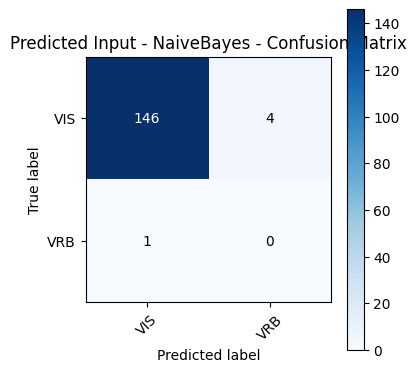

AUC Score: 0.33666666666666667


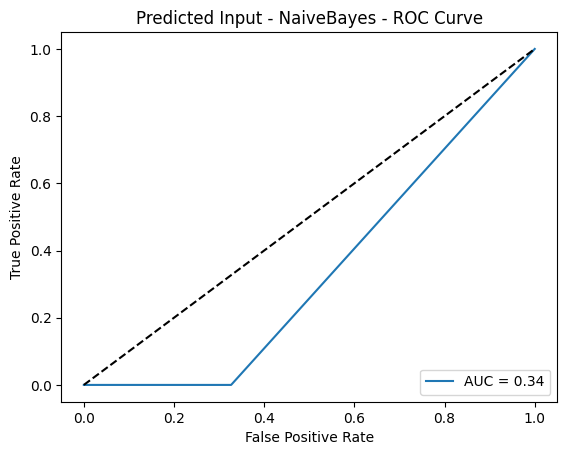


📌 Model: SVM
Accuracy: 0.9933774834437086
Precision: 0.9867988246129555
Recall: 0.9933774834437086
Specificity: 1.0
F1 Score: 0.9900772260236298
Cohen Kappa: 0.0
Log Loss: 0.05917715509741094
Train Time (s): 0.017467498779296875
Test Time (s): 0.0016741752624511719
Confusion Matrix:
 [[150   0]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


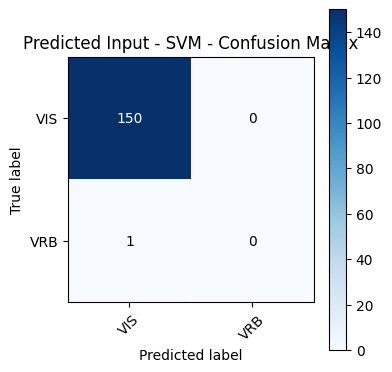

AUC Score: 0.6133333333333333


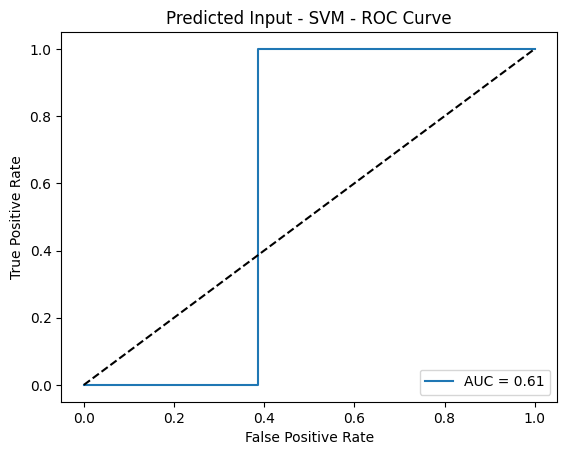


📌 Model: KNN
Accuracy: 0.9933774834437086
Precision: 0.9867988246129555
Recall: 0.9933774834437086
Specificity: 1.0
F1 Score: 0.9900772260236298
Cohen Kappa: 0.0
Log Loss: 0.24017746318166483
Train Time (s): 0.0019524097442626953
Test Time (s): 0.013089418411254883
Confusion Matrix:
 [[150   0]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.00      0.00      0.00         1

    accuracy                           0.99       151
   macro avg       0.50      0.50      0.50       151
weighted avg       0.99      0.99      0.99       151



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


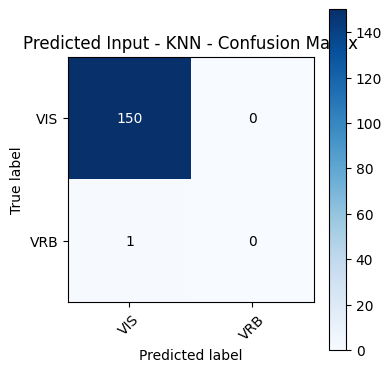

AUC Score: 0.49666666666666665


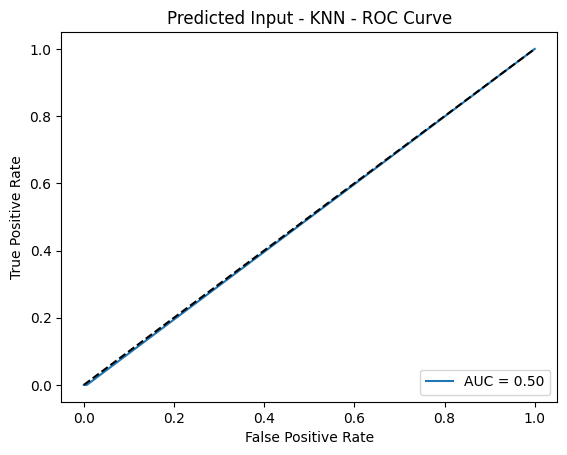


📌 Model: DecisionTree
Accuracy: 0.9801324503311258
Precision: 0.9867105204675765
Recall: 0.9801324503311258
Specificity: 0.9866666666666667
F1 Score: 0.9834104852820661
Cohen Kappa: -0.008908685968819663
Log Loss: 0.7160990739559702
Train Time (s): 0.003230571746826172
Test Time (s): 0.0003643035888671875
Confusion Matrix:
 [[148   2]
 [  1   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.00      0.00      0.00         1

    accuracy                           0.98       151
   macro avg       0.50      0.49      0.49       151
weighted avg       0.99      0.98      0.98       151



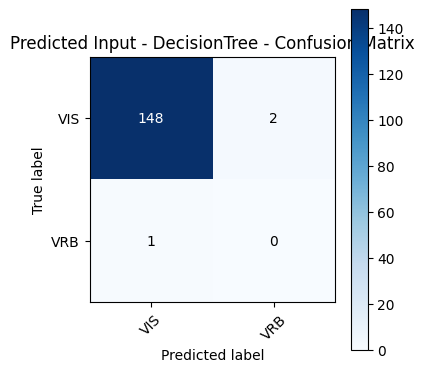

AUC Score: 0.49333333333333335


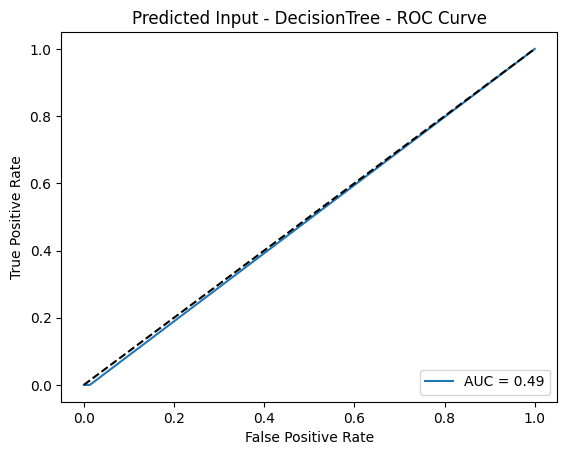


 FILE: Unlabelled_with_Predicted_LabelsUnderstanding.csv | TARGET: Predicted Understanding
✅ SMOTE Applied → Class Distribution: [677 677]

📌 Model: RandomForest
Accuracy: 0.9520295202952029
Precision: 0.9551450411326912
Recall: 0.9520295202952029
Specificity: 0.9923664122137404
F1 Score: 0.9520151494664177
Cohen Kappa: 0.9042116425133908
Log Loss: 0.13609506970395915
Train Time (s): 0.4029555320739746
Test Time (s): 0.011874198913574219
Confusion Matrix:
 [[130   1]
 [ 12 128]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       131
           1       0.99      0.91      0.95       140

    accuracy                           0.95       271
   macro avg       0.95      0.95      0.95       271
weighted avg       0.96      0.95      0.95       271



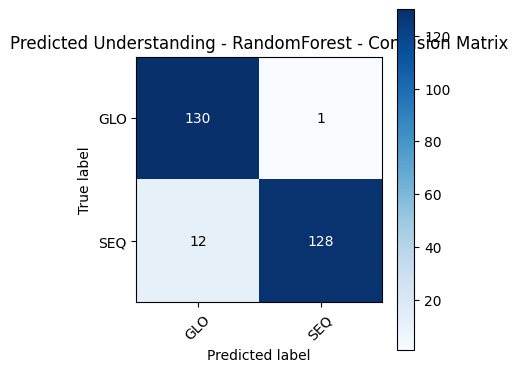

AUC Score: 0.9943565976008724


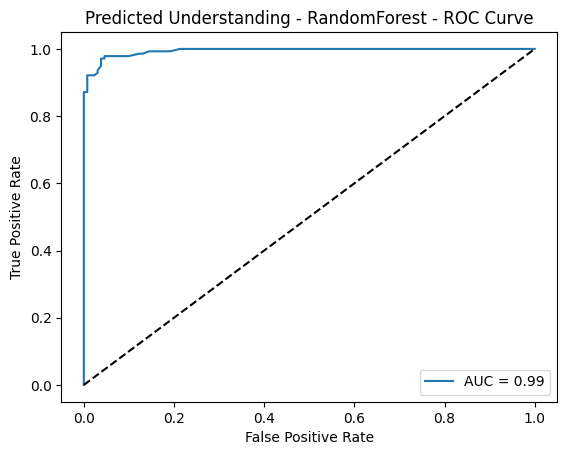


📌 Model: XGBoost
Accuracy: 0.959409594095941
Precision: 0.961528246689228
Recall: 0.959409594095941
Specificity: 0.9923664122137404
F1 Score: 0.959409594095941
Cohen Kappa: 0.9189086259894997
Log Loss: 0.12519436466326467
Train Time (s): 0.5646927356719971
Test Time (s): 0.0014700889587402344
Confusion Matrix:
 [[130   1]
 [ 10 130]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       131
           1       0.99      0.93      0.96       140

    accuracy                           0.96       271
   macro avg       0.96      0.96      0.96       271
weighted avg       0.96      0.96      0.96       271



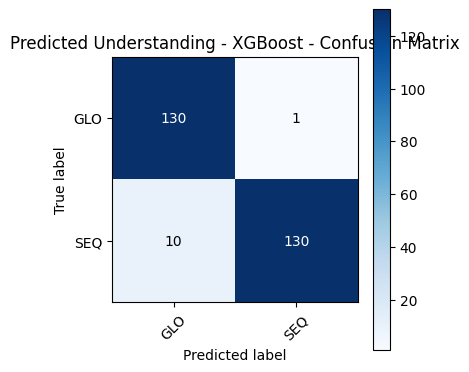

AUC Score: 0.9935114503816794


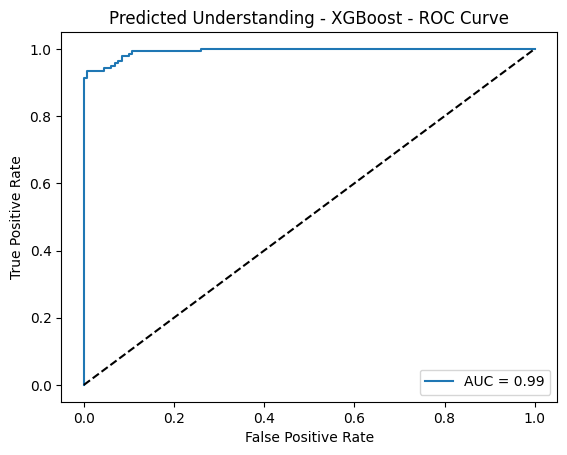


📌 Model: AdaBoost
Accuracy: 0.8966789667896679
Precision: 0.8976088126716325
Recall: 0.8966789667896679
Specificity: 0.916030534351145
F1 Score: 0.8967042933312
Cohen Kappa: 0.7934338759732128
Log Loss: 0.5322449023018778
Train Time (s): 0.20946025848388672
Test Time (s): 0.018201828002929688
Confusion Matrix:
 [[120  11]
 [ 17 123]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       131
           1       0.92      0.88      0.90       140

    accuracy                           0.90       271
   macro avg       0.90      0.90      0.90       271
weighted avg       0.90      0.90      0.90       271



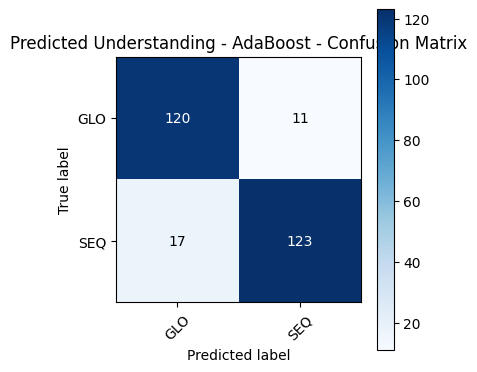

AUC Score: 0.9731461286804798


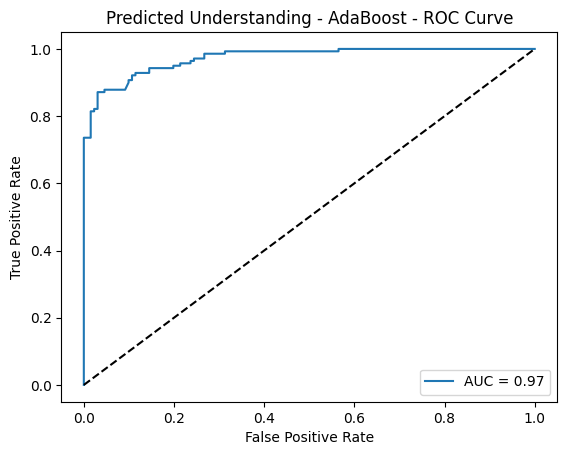


📌 Model: Bagging
Accuracy: 0.9298892988929889
Precision: 0.9340861912556134
Recall: 0.9298892988929889
Specificity: 0.9770992366412213
F1 Score: 0.9298396460981974
Cohen Kappa: 0.8600701144115009
Log Loss: 0.5050811889304437
Train Time (s): 0.10223770141601562
Test Time (s): 0.004392385482788086
Confusion Matrix:
 [[128   3]
 [ 16 124]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       131
           1       0.98      0.89      0.93       140

    accuracy                           0.93       271
   macro avg       0.93      0.93      0.93       271
weighted avg       0.93      0.93      0.93       271



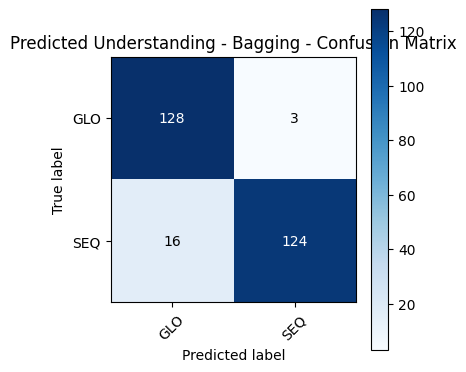

AUC Score: 0.9820338058887678


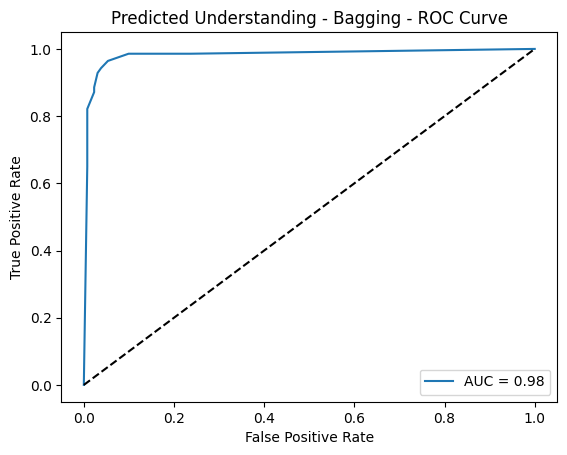


📌 Model: ExtraTrees
Accuracy: 0.955719557195572
Precision: 0.9583144603950131
Recall: 0.955719557195572
Specificity: 0.9923664122137404
F1 Score: 0.9557135277235126
Cohen Kappa: 0.9115583355996737
Log Loss: 0.13835029135047217
Train Time (s): 0.18095135688781738
Test Time (s): 0.009333372116088867
Confusion Matrix:
 [[130   1]
 [ 11 129]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       131
           1       0.99      0.92      0.96       140

    accuracy                           0.96       271
   macro avg       0.96      0.96      0.96       271
weighted avg       0.96      0.96      0.96       271



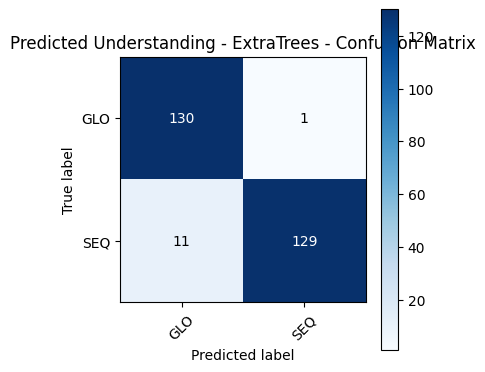

AUC Score: 0.9973555070883315


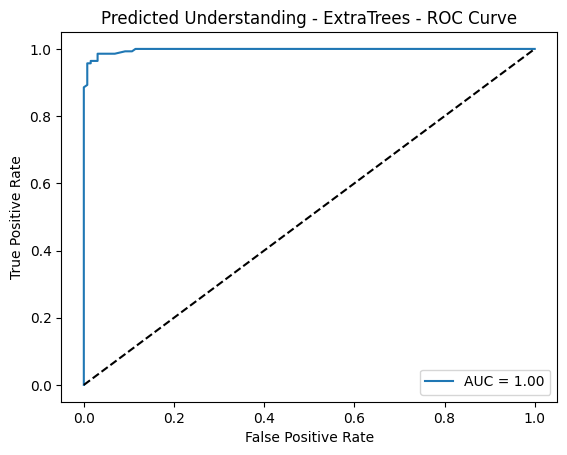


📌 Model: LogisticRegression
Accuracy: 0.8081180811808119
Precision: 0.8111081722705339
Recall: 0.8081180811808119
Specificity: 0.8473282442748091
F1 Score: 0.8080240111694068
Cohen Kappa: 0.6169403066217245
Log Loss: 0.4205412942009612
Train Time (s): 0.021767854690551758
Test Time (s): 0.00031065940856933594
Confusion Matrix:
 [[111  20]
 [ 32 108]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.81       131
           1       0.84      0.77      0.81       140

    accuracy                           0.81       271
   macro avg       0.81      0.81      0.81       271
weighted avg       0.81      0.81      0.81       271



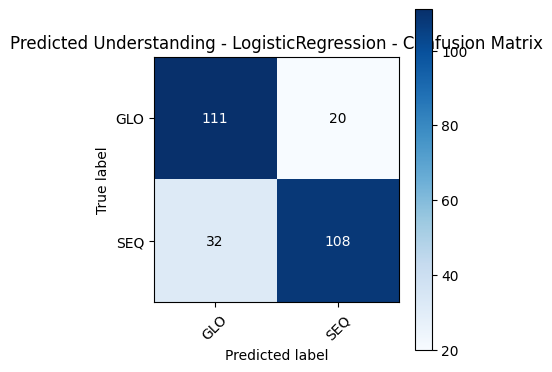

AUC Score: 0.8905670665212649


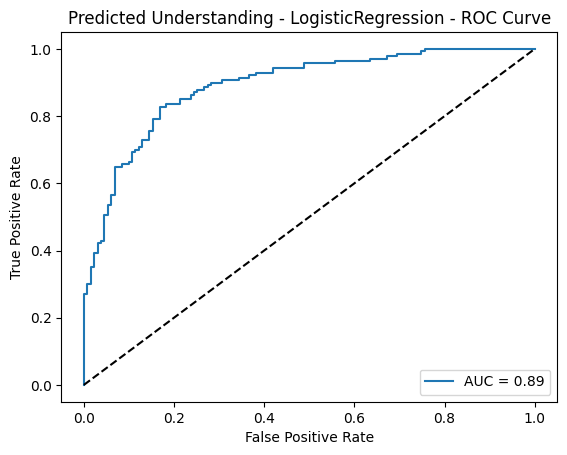


📌 Model: NaiveBayes
Accuracy: 0.6678966789667896
Precision: 0.7338033081823356
Recall: 0.6678966789667896
Specificity: 0.9236641221374046
F1 Score: 0.6475570177388521
Cohen Kappa: 0.3462878584829805
Log Loss: 1.9333417676595042
Train Time (s): 0.0019147396087646484
Test Time (s): 0.00041413307189941406
Confusion Matrix:
 [[121  10]
 [ 80  60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.92      0.73       131
           1       0.86      0.43      0.57       140

    accuracy                           0.67       271
   macro avg       0.73      0.68      0.65       271
weighted avg       0.73      0.67      0.65       271



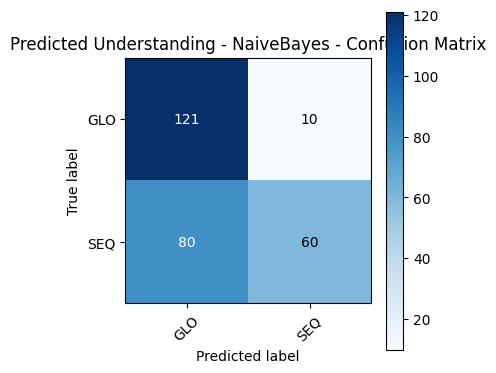

AUC Score: 0.8209378407851691


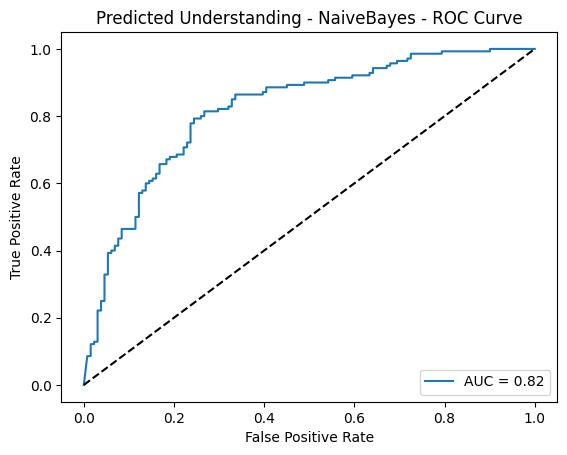


📌 Model: SVM
Accuracy: 0.8487084870848709
Precision: 0.8580006968800338
Recall: 0.8487084870848709
Specificity: 0.9236641221374046
F1 Score: 0.8481883367205366
Cohen Kappa: 0.6986357102172557
Log Loss: 0.32958873260071575
Train Time (s): 0.137376070022583
Test Time (s): 0.005688190460205078
Confusion Matrix:
 [[121  10]
 [ 31 109]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.86       131
           1       0.92      0.78      0.84       140

    accuracy                           0.85       271
   macro avg       0.86      0.85      0.85       271
weighted avg       0.86      0.85      0.85       271



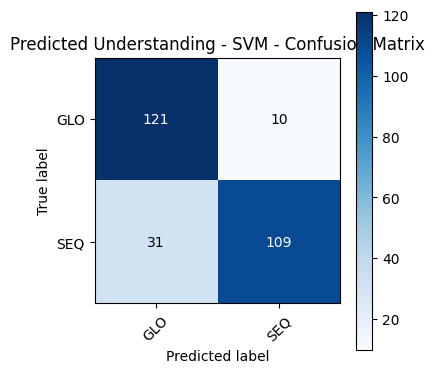

AUC Score: 0.9374591057797166


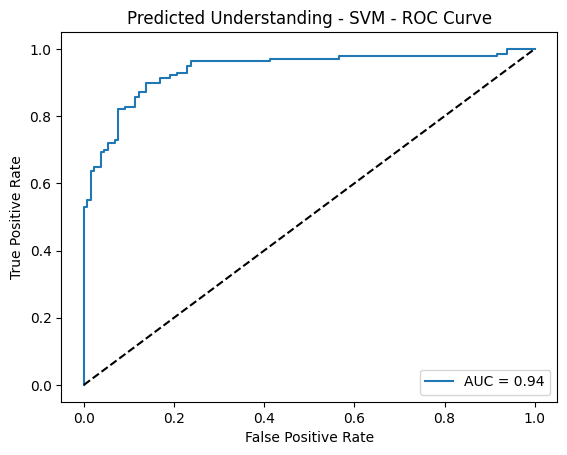


📌 Model: KNN
Accuracy: 0.8819188191881919
Precision: 0.9051004006972586
Recall: 0.8819188191881919
Specificity: 1.0
F1 Score: 0.8807268652015026
Cohen Kappa: 0.7654187405323523
Log Loss: 1.4517168290278486
Train Time (s): 0.002753734588623047
Test Time (s): 0.022447824478149414
Confusion Matrix:
 [[131   0]
 [ 32 108]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89       131
           1       1.00      0.77      0.87       140

    accuracy                           0.88       271
   macro avg       0.90      0.89      0.88       271
weighted avg       0.91      0.88      0.88       271



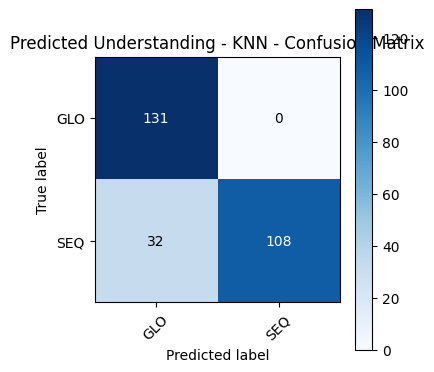

AUC Score: 0.9607415485278081


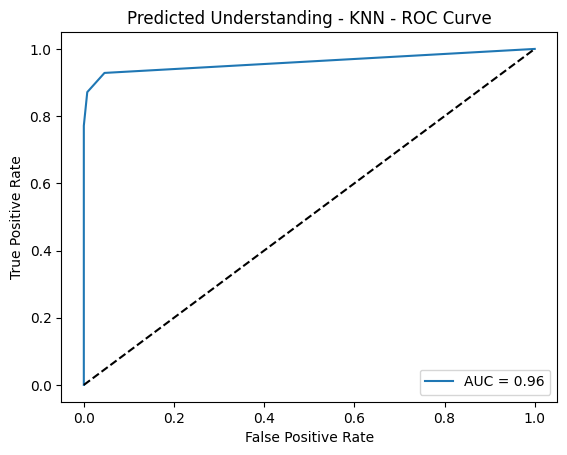


📌 Model: DecisionTree
Accuracy: 0.940959409594096
Precision: 0.9426133698877864
Recall: 0.940959409594096
Specificity: 0.9694656488549618
F1 Score: 0.9409658410309594
Cohen Kappa: 0.8820200261210274
Log Loss: 2.1280385764792413
Train Time (s): 0.013135671615600586
Test Time (s): 0.00035071372985839844
Confusion Matrix:
 [[127   4]
 [ 12 128]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       131
           1       0.97      0.91      0.94       140

    accuracy                           0.94       271
   macro avg       0.94      0.94      0.94       271
weighted avg       0.94      0.94      0.94       271



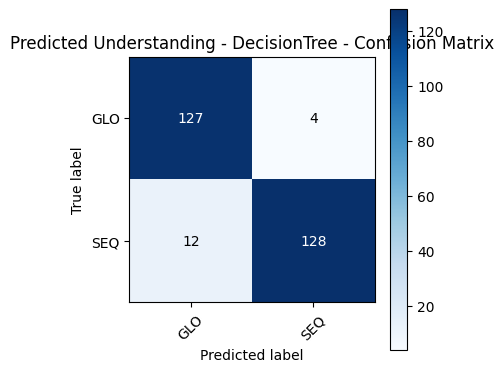

AUC Score: 0.941875681570338


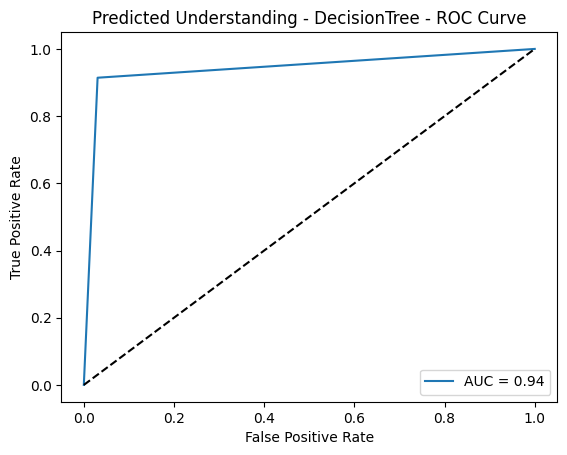

In [ ]:
# INSTALL LIBRARIES (uncomment if needed)
# !pip install imbalanced-learn scikit-learn matplotlib

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, classification_report, cohen_kappa_score, log_loss
from imblearn.over_sampling import SMOTE

# FILES AND TARGET COLUMNS
files_targets = {
    "Unlabelled_with_Predicted_LabelsProcessing.csv": "Predicted Processing",
    "Unlabelled_with_Predicted_LabelsPerception.csv": "Predicted Perception",
    "Unlabelled_with_Predicted_LabelsInput.csv": "Predicted Input",
    "Unlabelled_with_Predicted_LabelsUnderstanding.csv": "Predicted Understanding"
}

# INPUT COLUMNS
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# LOOP THROUGH FILES
for file, target_column in files_targets.items():
    print("\n=============================")
    print(" FILE:", file, "| TARGET:", target_column)
    print("=============================")

    # Load data
    df = pd.read_csv("/content/" + file)
    X = df[input_cols]
    y = df[target_column]

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Scale inputs
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # SMOTE -> Safe Handling
    class_counts = Counter(y_encoded)
    min_class_samples = min(class_counts.values())

    if min_class_samples > 5:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)
        print("✅ SMOTE Applied → Class Distribution:", np.bincount(y_balanced))
    else:
        X_balanced, y_balanced = X_scaled, y_encoded
        print("⚠️ SMOTE Skipped → Not enough samples in smallest class:", min_class_samples)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

    # Models
    models = {
        "RandomForest": RandomForestClassifier(),
        "XGBoost": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Bagging": BaggingClassifier(),
        "ExtraTrees": ExtraTreesClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "NaiveBayes": GaussianNB(),
        "SVM": SVC(probability=True),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier()
    }

    # Train + Evaluate
    for name, model in models.items():
        start_train = time.time()
        model.fit(X_train, y_train)
        end_train = time.time()
        train_time = end_train - start_train

        start_test = time.time()
        y_pred = model.predict(X_test)
        end_test = time.time()
        test_time = end_test - start_test

        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") and len(np.unique(y_train)) == 2 else None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        precision = precision_score(y_test, y_pred, average="weighted")
        recall = recall_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred, labels=le.transform(le.classes_))
        kappa = cohen_kappa_score(y_test, y_pred)
        logloss = log_loss(y_test, model.predict_proba(X_test)) if hasattr(model, "predict_proba") else "N/A"

        # Safe Specificity Calculation
        if cm.shape[0] > 1:
            specificity = cm[0][0] / (cm[0][0] + cm[0][1]) if (cm[0][0] + cm[0][1]) != 0 else 0
        else:
            specificity = "N/A (Only one class in y_test)"

        print("\n📌 Model:", name)
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("Specificity:", specificity)
        print("F1 Score:", f1)
        print("Cohen Kappa:", kappa)
        print("Log Loss:", logloss)
        print("Train Time (s):", train_time)
        print("Test Time (s):", test_time)
        print("Confusion Matrix:\n", cm)
        print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

        # Confusion Matrix plot
        if cm.shape[0] > 1:
            plt.figure(figsize=(4, 4))
            plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            plt.title(f"{target_column} - {name} - Confusion Matrix")
            plt.colorbar()
            plt.xticks(np.arange(len(le.classes_)), le.classes_, rotation=45)
            plt.yticks(np.arange(len(le.classes_)), le.classes_)
            plt.xlabel('Predicted label')
            plt.ylabel('True label')

            thresh = cm.max() / 2
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                             color="white" if cm[i, j] > thresh else "black")
            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ Skipping confusion matrix plot (only one class in test set)")

        # ROC Curve
        if y_proba is not None and len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba)
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            print("AUC Score:", auc)

            plt.figure()
            plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.title(f"{target_column} - {name} - ROC Curve")
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend(loc='lower right')
            plt.show()
        else:
            print("⚠️ ROC curve not plotted (requires binary classification with probability output)")


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Processing dataset
file_path = "Unlabelled_with_Predicted_LabelsProcessing.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Processing"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  #  0= ACT,  1=REF

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("ACT")
    else:
        feature_direction.append("REF")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in ACT or REF ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)

# Optional → Save to Excel
final_df.to_excel("Processing_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Processing_Feature_Engineering_Report.xlsx")


# Create lists to hold features for ACT and REF
act_features = direction_df[direction_df["Higher In"] == "ACT"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "REF"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with ACT:")
print(act_features)

print("\n Features more associated with REF:")
print(ref_features)




=== Chi2 Feature Importance ===
               Feature    Chi2 Score        p-value
8              playing  47392.519589   0.000000e+00
11           buffering  35890.950517   0.000000e+00
9               paused  20691.133209   0.000000e+00
10           unstarted   1470.922850   0.000000e+00
4     Visual Materials   1073.707391  1.711970e-235
5      Self-assessment    232.719718   1.521361e-52
1         Reading file     38.823984   4.637941e-10
3    Concrete material     33.746287   6.278876e-09
2   Abstract materiale     22.491837   2.110385e-06
6     Exercises submit     16.323149   5.340753e-05
7       Quiz submitted      3.686377   5.485865e-02
0      Course overview      0.226604   6.340533e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
8              playing  0.111577
9               paused  0.089942
11           buffering  0.087266
10           unstarted  0.077867
6     Exercises submit  0.054753
1         Reading file  0.054626
4     Visual 

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Input dataset
file_path = "Unlabelled_with_Predicted_LabelsInput.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Input"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0 =VIS, 1=VRB

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("VIS")
    else:
        feature_direction.append("VRB")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in VIS or VRB ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)
# Create lists to hold features for VIS and VRB
act_features = direction_df[direction_df["Higher In"] == "VIS"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "VRB"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with VIS:")
print(act_features)

print("\n Features more associated with VRB:")
print(ref_features)

# Optional → Save to Excel
final_df.to_excel("Input_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Input_Feature_Engineering_Report.xlsx")


=== Chi2 Feature Importance ===
               Feature   Chi2 Score       p-value
9               paused  7957.003324  0.000000e+00
8              playing  4771.662716  0.000000e+00
11           buffering  4450.025709  0.000000e+00
1         Reading file   284.393881  8.281697e-64
3    Concrete material   173.533551  1.251552e-39
10           unstarted   146.850472  8.460945e-34
2   Abstract materiale   145.335343  1.814042e-33
4     Visual Materials    78.359329  8.590270e-19
5      Self-assessment    64.317991  1.058745e-15
7       Quiz submitted     2.302445  1.291705e-01
0      Course overview     1.809822  1.785296e-01
6     Exercises submit     0.004749  9.450590e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
2   Abstract materiale  0.000489
0      Course overview  0.000272
1         Reading file  0.000000
3    Concrete material  0.000000
4     Visual Materials  0.000000
5      Self-assessment  0.000000
6     Exercises submit  0.000000
7     

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Perception dataset
file_path = "Unlabelled_with_Predicted_LabelsPerception.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Perception"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  #  0= SEN,  1=INT

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("SEN")
    else:
        feature_direction.append("INT")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in SEN or INT ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)

# Create lists to hold features for ACT and REF
act_features = direction_df[direction_df["Higher In"] == "SEN"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "INT"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with SEN:")
print(act_features)

print("\n Features more associated with INT:")
print(ref_features)


# Optional → Save to Excel
final_df.to_excel("Perception_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Perception_Feature_Engineering_Report.xlsx")


=== Chi2 Feature Importance ===
               Feature  Chi2 Score        p-value
8              playing  907.203787  2.665698e-199
11           buffering  644.413481  3.665025e-142
9               paused  478.547873  4.423074e-106
3    Concrete material  127.784685   1.251049e-29
1         Reading file  121.895657   2.433032e-28
5      Self-assessment  103.428321   2.699875e-24
4     Visual Materials  100.963623   9.368835e-24
10           unstarted   58.790052   1.754260e-14
2   Abstract materiale   14.044938   1.784936e-04
6     Exercises submit    7.149229   7.499621e-03
7       Quiz submitted    1.784914   1.815471e-01
0      Course overview    0.000335   9.853945e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
5      Self-assessment  0.049306
1         Reading file  0.027519
3    Concrete material  0.024790
10           unstarted  0.007557
4     Visual Materials  0.004786
8              playing  0.004395
9               paused  0.004227
11    

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the Understanding Processing dataset
file_path = "Unlabelled_with_Predicted_LabelsUnderstanding.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Understanding"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  #  0=SEQ,  1=GLO

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("SEQ")
    else:
        feature_direction.append("GLO")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in SEQ or GLO ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)

# Create lists to hold features for ACT and REF
act_features = direction_df[direction_df["Higher In"] == "SEQ"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "GLO"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with SEQ:")
print(act_features)

print("\n Features more associated with GLO:")
print(ref_features)


# Optional → Save to Excel
final_df.to_excel("Understanding_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Understanding_Feature_Engineering_Report.xlsx")


=== Chi2 Feature Importance ===
               Feature   Chi2 Score        p-value
8              playing  2605.922970   0.000000e+00
9               paused  2000.543212   0.000000e+00
11           buffering  1912.182801   0.000000e+00
1         Reading file   713.997080  2.703894e-157
3    Concrete material   666.367945  6.158472e-147
5      Self-assessment   481.509090  1.003160e-106
4     Visual Materials   473.984131  4.353117e-105
10           unstarted   234.045995   7.816479e-53
2   Abstract materiale    94.936831   1.965585e-22
6     Exercises submit    47.704789   4.954798e-12
7       Quiz submitted    33.999501   5.512620e-09
0      Course overview     0.021258   8.840792e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
5      Self-assessment  0.118849
3    Concrete material  0.096937
1         Reading file  0.076341
4     Visual Materials  0.066619
6     Exercises submit  0.059837
2   Abstract materiale  0.032869
10           unstarted  0.